# 02 · Preparación del dataset
Partición **estratificada 70 / 15 / 15** (train / val / test) con semilla fija, y construcción de los pipelines de datos con *data augmentation* solo en entrenamiento.

> La partición se hace **una sola vez** y se guarda en Drive. El conjunto de **test no se toca** hasta la evaluación final.

In [1]:
# =========================================================
# CONFIGURACIÓN  ·  EDITAR BASE_DIR si hace falta
# =========================================================
from google.colab import drive
drive.mount('/content/drive')

import os

# Carpeta de Drive que CONTIENE "Imagenes OK" y "Imagenes Patologicas".
# Ajustá esta ruta a donde estén tus carpetas.
BASE_DIR = '/content/drive/MyDrive/TP_Final Aprendizaje Automatico'

OK_DIR  = os.path.join(BASE_DIR, 'Imagenes OK')
PAT_DIR = os.path.join(BASE_DIR, 'Imagenes Patologicas')

# Carpeta donde se guardará la partición train/val/test (notebook 02)
DATASET_DIR = os.path.join(BASE_DIR, 'dataset')
# Carpeta donde se guardarán los modelos entrenados
MODELS_DIR  = os.path.join(BASE_DIR, 'modelos')
os.makedirs(MODELS_DIR, exist_ok=True)

# Hiperparámetros globales compartidos
IMG_SIZE = (224, 224)
BATCH    = 32
SEED     = 42

# Las carpetas se ordenan alfabéticamente: 'ok'=0, 'patologica'=1
# => la clase POSITIVA (la que nos importa) es 'patologica' = 1
CLASS_NAMES = ['ok', 'patologica']
print('OK_DIR :', OK_DIR)
print('PAT_DIR:', PAT_DIR)

Mounted at /content/drive
OK_DIR : /content/drive/MyDrive/TP_Final Aprendizaje Automatico/Imagenes OK
PAT_DIR: /content/drive/MyDrive/TP_Final Aprendizaje Automatico/Imagenes Patologicas


## 1. Partición estratificada

Recorremos **recursivamente** las imágenes de cada clase con `rglob` (así se incluyen las que están dentro de subcarpetas, p. ej. en `Imagenes Patologicas`) y las repartimos manteniendo la proporción de clases en los tres subconjuntos.

Las imágenes se **copian, no se mueven**: tus carpetas originales quedan intactas. Las copias se guardan aplanadas en `dataset/<split>/<clase>/`, con un **prefijo numérico** para evitar choques de nombres entre subcarpetas distintas.

Hacemos dos cortes:
1. `train` (70%) vs `temp` (30%)
2. `temp` → `val` (15%) y `test` (15%)

In [2]:
import shutil
from pathlib import Path
from sklearn.model_selection import train_test_split

VALID_EXT = {'.jpg', '.jpeg', '.png', '.bmp', '.gif', '.tif', '.tiff', '.webp'}
def listar(carpeta):
    # rglob('*') -> incluye imágenes dentro de subcarpetas
    return [p for p in Path(carpeta).rglob('*')
            if p.suffix.lower() in VALID_EXT and p.is_file()]

origen = {'ok': listar(OK_DIR), 'patologica': listar(PAT_DIR)}
print('Encontradas -> ok:', len(origen['ok']), '| patologica:', len(origen['patologica']))

# Reiniciamos la carpeta de salida
if os.path.exists(DATASET_DIR):
    shutil.rmtree(DATASET_DIR)
for split in ['train', 'val', 'test']:
    for clase in CLASS_NAMES:
        os.makedirs(os.path.join(DATASET_DIR, split, clase), exist_ok=True)

def copiar(files, split, clase):
    # Copia (no mueve). Prefijo numérico para evitar choques de nombres
    # entre imágenes que vienen de subcarpetas distintas.
    destino = os.path.join(DATASET_DIR, split, clase)
    for i, f in enumerate(files):
        nombre = f'{i:04d}_{f.name}'
        shutil.copy(f, os.path.join(destino, nombre))

for clase, files in origen.items():
    train, temp = train_test_split(files, test_size=0.30, random_state=SEED)
    val, test   = train_test_split(temp,  test_size=0.50, random_state=SEED)  # 0.5*0.3 = 0.15
    copiar(train, 'train', clase)
    copiar(val,   'val',   clase)
    copiar(test,  'test',  clase)
    print(f'{clase:11s} -> train {len(train)}  val {len(val)}  test {len(test)}')
print('\nPartición creada en:', DATASET_DIR)
print('(las carpetas originales NO se modificaron)')

Encontradas -> ok: 245 | patologica: 196
ok          -> train 171  val 37  test 37
patologica  -> train 137  val 29  test 30

Partición creada en: /content/drive/MyDrive/TP_Final Aprendizaje Automatico/dataset
(las carpetas originales NO se modificaron)


In [3]:
print(f'Contents of BASE_DIR ({BASE_DIR}):')
print(os.listdir(BASE_DIR))

Contents of BASE_DIR (/content/drive/MyDrive/TP_Final Aprendizaje Automatico):
['Imagenes OK', 'Imagenes Patologicas', 'Imagenes', 'contar_imagenes_dataset.ipynb', 'modelos', '02_preparacion_dataset.ipynb', '05_evaluacion_comparacion.ipynb', '06_gradcam.ipynb', '04_transfer_learning.ipynb', '03_cnn_desde_cero .ipynb', '01_exploracion_dataset.ipynb', 'dataset']


In [4]:
for item in os.listdir(BASE_DIR):
    item_path = os.path.join(BASE_DIR, item)
    if os.path.isdir(item_path):
        print(f'Contents of {item_path}:')
        print(os.listdir(item_path))
    else:
        print(f'File in BASE_DIR: {item_path}')

Contents of /content/drive/MyDrive/TP_Final Aprendizaje Automatico/Imagenes OK:
['TEO_Torax-LLD-04_02_2026-06_24_23 p.m.-825.JPEG', 'TEO_Torax-LLD-04_02_2026-06_24_25 p.m.-338.JPEG', 'TEO_Torax-LLD-04_02_2026-06_24_24 p.m.-824.JPEG', 'POPY_Abdomen-LLD-05_02_2026-12_01_57 p.m.-189.JPEG', 'Branca_Nazar_Guillermo_Torax-LLD-06_02_2026-08_15_23 p.m.-534.JPEG', 'Branca_Nazar_Guillermo_Torax-LLI-06_02_2026-08_15_24 p.m.-96.JPEG', 'Branca_Nazar_Guillermo_Torax-VD-06_02_2026-08_15_24 p.m.-658.JPEG', 'Aguirre_Alfaro_Analia_Torax-LLI-06_02_2026-08_40_51 p.m.-172.JPEG', 'PATATA_NORA_CONCINA_Columna-Cervical DV-10_02_2026-12_27_54 p.m.-405.JPEG', 'PATATA_NORA_CONCINA_Columna-Toracica LL-10_02_2026-12_27_54 p.m.-966.JPEG', 'Azor_Cecilia_Jim_Torax-VD-11_02_2026-09_23_14 a.m.-336.JPEG', 'Azor_Cecilia_Jim_Torax-VD-11_02_2026-09_23_13 a.m.-821.JPEG', 'Azor_Cecilia_Jim_Torax-VD-11_02_2026-09_23_16 a.m.-286.JPEG', 'Indio_Miranda_Patricia_Abdomen-LLI-18_02_2026-10_29_13 a.m.-47.JPEG', 'Indio_Miranda_Patric

In [5]:
# Introduce the path where you believe your 'Imagenes OK' and 'Imagenes Patologicas' folders are located
# For example: '/content/drive/MyDrive/TP_Final Aprendizaje Automatico/MyImageFolder'
# Make sure this path is the parent directory that directly contains 'Imagenes OK' and 'Imagenes Patologicas'
path_to_check = 'YOUR_PATH_HERE' # <--- Please replace 'YOUR_PATH_HERE' with the actual path

if path_to_check == 'YOUR_PATH_HERE':
    print("Please update 'path_to_check' with the correct path to your image directory.")
else:
    print(f"Contents of {path_to_check}:")
    try:
        print(os.listdir(path_to_check))
    except FileNotFoundError:
        print(f"Error: The directory '{path_to_check}' was not found. Please check the path.")
    except Exception as e:
        print(f"An unexpected error occurred: {e}")

Please update 'path_to_check' with the correct path to your image directory.


## 2. Verificación de la partición

In [6]:
import pandas as pd
filas = []
for split in ['train', 'val', 'test']:
    fila = {'split': split}
    for clase in CLASS_NAMES:
        fila[clase] = len(os.listdir(os.path.join(DATASET_DIR, split, clase)))
    fila['total'] = fila['ok'] + fila['patologica']
    filas.append(fila)
df = pd.DataFrame(filas)
df.loc['TOTAL'] = ['TOTAL', df['ok'].sum(), df['patologica'].sum(), df['total'].sum()]
df

,split,ok,patologica,total
0,train,171,137,308
1,val,37,29,66
2,test,37,30,67
TOTAL,TOTAL,245,196,441


## 3. Pipelines de datos (tf.data)

In [7]:
import tensorflow as tf

def make_ds(subset, shuffle):
    return tf.keras.utils.image_dataset_from_directory(
        os.path.join(DATASET_DIR, subset),
        labels='inferred', label_mode='int', class_names=CLASS_NAMES,
        color_mode='rgb', image_size=IMG_SIZE, batch_size=BATCH,
        shuffle=shuffle, seed=SEED)

train_ds = make_ds('train', True)
val_ds   = make_ds('val',   False)
test_ds  = make_ds('test',  False)
print('Clases (0,1):', train_ds.class_names)

Found 308 files belonging to 2 classes.
Found 66 files belonging to 2 classes.
Found 67 files belonging to 2 classes.
Clases (0,1): ['ok', 'patologica']


## 4. Data augmentation (solo se aplicará en train)

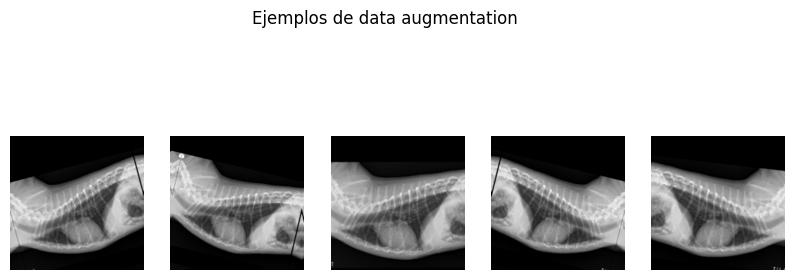

In [8]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip('horizontal'),
    tf.keras.layers.RandomRotation(0.05),    # rotaciones leves (~±18°·0.05)
    tf.keras.layers.RandomZoom(0.10),
    tf.keras.layers.RandomContrast(0.10),
], name='data_augmentation')

# Visualizamos el efecto sobre una imagen
import matplotlib.pyplot as plt
for images, _ in train_ds.take(1):
    plt.figure(figsize=(10, 4))
    for i in range(5):
        aug = data_augmentation(tf.expand_dims(images[0], 0), training=True)
        ax = plt.subplot(1, 5, i+1)
        plt.imshow(aug[0].numpy().astype('uint8'))
        plt.axis('off')
    plt.suptitle('Ejemplos de data augmentation')
    plt.show()

## 5. Pesos de clase (salvaguarda ante el desbalance)

In [9]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

n_ok  = len(os.listdir(os.path.join(DATASET_DIR, 'train', 'ok')))
n_pat = len(os.listdir(os.path.join(DATASET_DIR, 'train', 'patologica')))
y_train = np.array([0]*n_ok + [1]*n_pat)

pesos = compute_class_weight('balanced', classes=np.array([0,1]), y=y_train)
class_weight = {0: float(pesos[0]), 1: float(pesos[1])}
print('class_weight =', class_weight)
# Guardamos para reutilizar en las notebooks de entrenamiento
import json
with open(os.path.join(DATASET_DIR, 'class_weight.json'), 'w') as f:
    json.dump(class_weight, f)

class_weight = {0: 0.9005847953216374, 1: 1.1240875912408759}


> **Nota:** los objetos `train_ds`/`val_ds`/`test_ds` no se transfieren entre notebooks. Lo que persiste es la **carpeta `dataset/` en Drive**; las notebooks 03–06 la reconstruyen desde ahí. El `class_weight` queda guardado en `dataset/class_weight.json`.

Próximo paso → **03_cnn_desde_cero.ipynb**.